Name: Prajakta Vishwajit Mahangare

Class:CSE(AI) SY(SEDA)

Rollno. 34  PRN NO. 12520047

Assignment No. 11

Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.
Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions
The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.
a.	Perform data-preparation (Train-Test Split)
b.	Apply Machine Learning Algorithm
c.	Evaluate Model.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree

In [ ]:
data = pd.read_csv("Admission_Predict.csv")
print(data.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


In [ ]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


Preprocessing


In [ ]:
# Drop serial number
data.drop(columns=["Serial No."], inplace=True, errors='ignore')

data['Admitted'] = data['Chance of Admit '] >= 0.75
data['Admitted'] = data['Admitted'].astype(int)

data.drop(columns=['Chance of Admit '], inplace=True, errors='ignore')

Define X and Y

In [ ]:
X = data[['GRE Score', 'CGPA']]
y = data['Admitted']

DATA VISUALIZATION

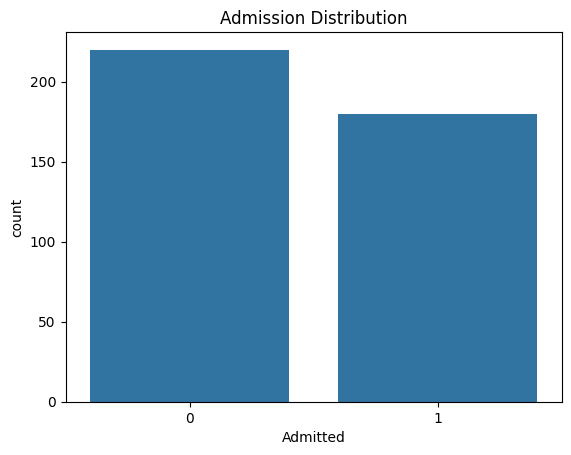

<Figure size 600x400 with 0 Axes>

In [ ]:
sns.countplot(x=y)
plt.title("Admission Distribution")
plt.figure(figsize=(6,4))
plt.tight_layout()
plt.show()

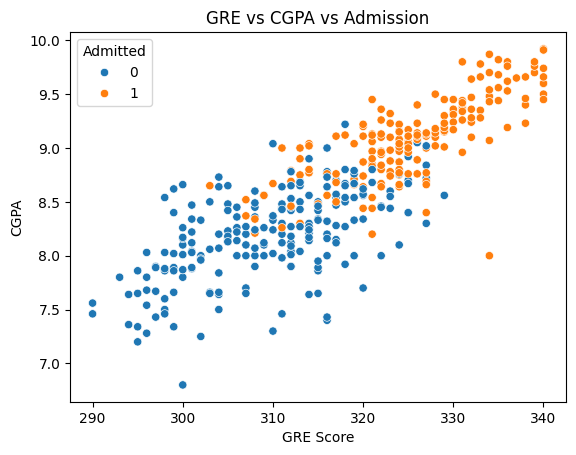

<Figure size 1000x600 with 0 Axes>

In [ ]:
sns.scatterplot(x='GRE Score', y='CGPA', hue='Admitted', data=data)
plt.title("GRE vs CGPA vs Admission")
plt.figure(figsize=(10,6))
plt.tight_layout()
plt.show()

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Apply Decision Tree Classifier

In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Predictions

In [ ]:
y_pred = model.predict(X_test)

Model Evaluation

Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.925

Confusion Matrix:
 [[43  4]
 [ 2 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93        47
           1       0.89      0.94      0.91        33

    accuracy                           0.93        80
   macro avg       0.92      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



Confusion Matrix

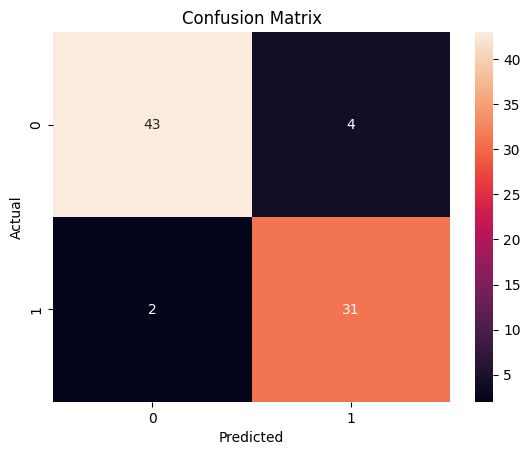

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93        47
           1       0.89      0.94      0.91        33

    accuracy                           0.93        80
   macro avg       0.92      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



Decision Tree Visualization

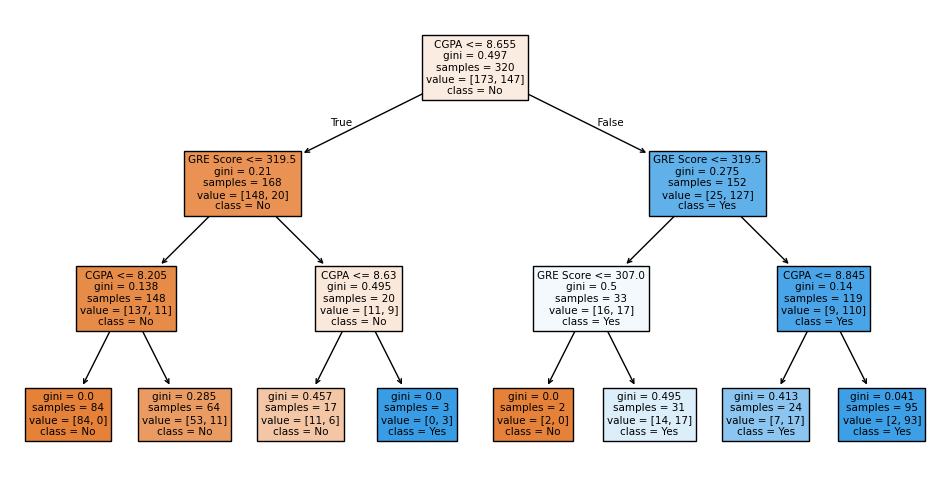

In [ ]:
plt.figure(figsize=(12,6))
tree.plot_tree(model, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.show()